### Autograd in Pytorch

This section demonstrates how to implement a basic linear regression model using PyTorch, including data generation, model definition, training loop, and visualization of predictions.

In [ ]:
import numpy as np
import torch
from torch.autograd import Variable
import matplotlib.pyplot as plt

# 1. Data Generation
# Create dummy data for training. We'll generate x_values from 0 to 19.
x_values = [i for i in range(20)]
# Convert x_values to a NumPy array of float32 and reshape for PyTorch.
x_train = np.array(x_values, dtype=np.float32)
x_train = x_train.reshape(-1, 1)

# Define the true relationship: y = 2*x + 1
y_values = [2*i + 1 for i in x_values]
# Convert y_values to a NumPy array of float32 and reshape for PyTorch.
y_train = np.array(y_values, dtype=np.float32)
y_train = y_train.reshape(-1, 1)

# Print the shapes of the generated training data.
print (x_train.shape, y_train.shape)

# 2. Model Definition
# Define a simple linear regression model using torch.nn.Module.
class linearRegression(torch.nn.Module):
    def __init__(self, inputSize, outputSize):
        super(linearRegression, self).__init__()
        # Linear layer that maps input to output.
        self.linear = torch.nn.Linear(inputSize, outputSize)

    def forward(self, x):
        # Forward pass applies the linear transformation.
        out = self.linear(x)
        return out

# Set hyperparameters.
inputDim = 1        # Input dimension (one feature: x)
outputDim = 1       # Output dimension (one target: y)
learningRate = 0.0001
epochs = 1000

# Instantiate the model.
model = linearRegression(inputDim, outputDim)

# Move the model to GPU if available.
if torch.cuda.is_available():
    model.cuda()

# 3. Loss Function and Optimizer
# Define the Mean Squared Error (MSE) loss function.
criterion = torch.nn.MSELoss()
# Define the Stochastic Gradient Descent (SGD) optimizer.
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

# 4. Training Loop
# Iterate over the specified number of epochs.
for epoch in range(epochs):
    # Convert inputs and labels to PyTorch Variables and move to GPU if available.
    if torch.cuda.is_available():
        inputs = Variable(torch.from_numpy(x_train).cuda())
        labels = Variable(torch.from_numpy(y_train).cuda())
    else:
        inputs = Variable(torch.from_numpy(x_train))
        labels = Variable(torch.from_numpy(y_train))

    # Clear gradients from the previous epoch.
    optimizer.zero_grad()

    # Perform a forward pass to get model predictions.
    outputs = model(inputs)

    # Calculate the loss.
    loss = criterion(outputs, labels)
    # Print the loss for each epoch. (Note: printing inside loop is for demonstration, usually done less frequently)
    print(loss)
    # Perform a backward pass to compute gradients.
    loss.backward()

    # Update model parameters using the optimizer.
    optimizer.step()

    # Print training progress.
    print('epoch {}, loss {}'.format(epoch, loss.item()))

# 5. Make Predictions and Visualize
# Disable gradient computation for inference.
with torch.no_grad():
    # Get predictions on the training data.
    if torch.cuda.is_available():
        predicted = model(Variable(torch.from_numpy(x_train).cuda())).cpu().data.numpy()
    else:
        predicted = model(Variable(torch.from_numpy(x_train))).data.numpy()
    # Print the predicted values.
    print(predicted)


(20, 1) (20, 1)
tensor(671.8080, grad_fn=<MseLossBackward0>)
epoch 0, loss 671.8079833984375
tensor(638.8797, grad_fn=<MseLossBackward0>)
epoch 1, loss 638.8796997070312
tensor(607.5674, grad_fn=<MseLossBackward0>)
epoch 2, loss 607.5674438476562
tensor(577.7919, grad_fn=<MseLossBackward0>)
epoch 3, loss 577.7918701171875
tensor(549.4774, grad_fn=<MseLossBackward0>)
epoch 4, loss 549.4774169921875
tensor(522.5526, grad_fn=<MseLossBackward0>)
epoch 5, loss 522.5525512695312
tensor(496.9490, grad_fn=<MseLossBackward0>)
epoch 6, loss 496.94903564453125
tensor(472.6020, grad_fn=<MseLossBackward0>)
epoch 7, loss 472.60198974609375
tensor(449.4499, grad_fn=<MseLossBackward0>)
epoch 8, loss 449.4498596191406
tensor(427.4339, grad_fn=<MseLossBackward0>)
epoch 9, loss 427.43389892578125
tensor(406.4984, grad_fn=<MseLossBackward0>)
epoch 10, loss 406.4984130859375
tensor(386.5903, grad_fn=<MseLossBackward0>)
epoch 11, loss 386.59027099609375
tensor(367.6592, grad_fn=<MseLossBackward0>)
epoch 12,

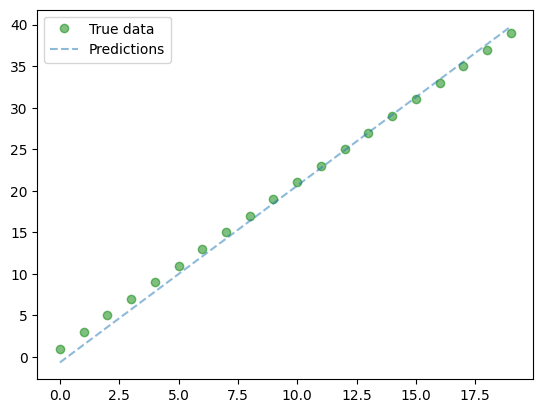

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

# Clear the current figure.
plt.clf()
# Plot the true data points in green circles.
plt.plot(x_train, y_train, 'go', label='True data', alpha=0.5)
# Plot the model's predictions as a dashed line.
plt.plot(x_train, predicted, '--', label='Predictions', alpha=0.5)
# Display the legend.
plt.legend(loc='best')
# Show the plot.
plt.show()


This section demonstrates how to implement a Logistic Regression model using PyTorch for binary classification, including data generation, model definition, training, and visualization of loss.

In [10]:
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import make_classification
from tqdm import tqdm

# 1. Data Generation
separable = False
while not separable:
    samples = make_classification(n_samples=1000, n_features=2, n_redundant=0, n_informative=2, n_clusters_per_class=1)
    red = samples[0][samples[1] == 0]
    blue = samples[0][samples[1] == 1]
    separable = any([red[:,k].max() < blue[:,k].min() or red[:,k].min() > blue[:,k].max() for k in range(2)])

red_labels = np.zeros(len(red))
blue_labels = np.ones(len(blue))
labels_lr = np.append(red_labels, blue_labels)
inputs_lr = np.concatenate((red, blue), axis=0)

# 2. Model Definition
class LogisticRegression(torch.nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogisticRegression, self).__init__()
        self.linear = torch.nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

model_logistic = LogisticRegression(2, 1)
criterion_lr = torch.nn.BCELoss()
optimizer_lr = torch.optim.SGD(model_logistic.parameters(), lr=0.01)

# Quick Training
X_train_t = torch.from_numpy(inputs_lr).float()
y_train_t = torch.from_numpy(labels_lr).float()

for epoch in range(1000):
    optimizer_lr.zero_grad()
    outputs = model_logistic(X_train_t)
    loss = criterion_lr(torch.squeeze(outputs), y_train_t)
    loss.backward()
    optimizer_lr.step()
print("Logistic Model Trained Successfully")

Logistic Model Trained Successfully


This section demonstrates the implementation of a shallow neural network for binary classification. It covers data generation, model definition, training process, and evaluation.

(4000, 2)
(4000,)


Text(0, 0.5, 'feature 2')

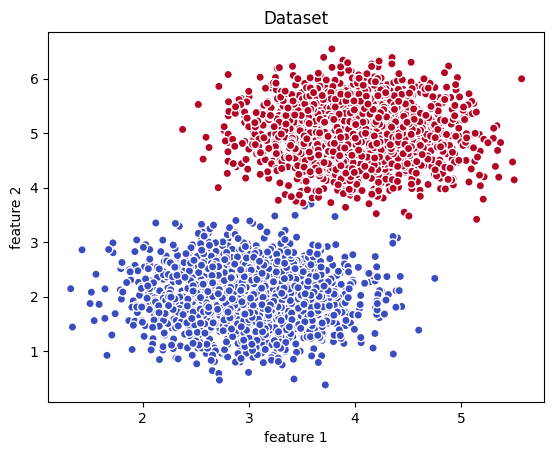

In [ ]:
# Necessary imports
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib.cm as cm

# This line detects if we have GPU support on our system
device = ("cuda" if torch.cuda.is_available() else "cpu")

# 1. Data Generation
# Generate two clusters of data points for feature 1 and feature 2.
x1 = np.random.randn(2000)*0.5+3
x2 = np.random.randn(2000)*0.5+2

x3 = np.random.randn(2000) *0.5 + 4
x4 = np.random.randn(2000) *0.5 + 5

# Create two classes of data by stacking x1,x2 and x3,x4.
X_1 = np.vstack([x1, x2])
X_2 = np.vstack([x3, x4])
# Combine the two classes into a single dataset X.
X = np.hstack([X_1, X_2]).T

# Create a vector that contains classes (0, 1) for the respective data points.
y = np.hstack([np.zeros(2000), np.ones(2000)])

# Print the shapes of the generated data.
print(X.shape)
print(y.shape)

# Visualize the dataset using a scatter plot.
plt.scatter(X[:,0], X[:,1], c=y, cmap=cm.coolwarm, edgecolors='w');
plt.title('Dataset')
plt.xlabel('feature 1')
plt.ylabel('feature 2')

In [ ]:
# Split the dataset into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

# Convert NumPy arrays into PyTorch tensors of type float.
X_train = torch.from_numpy(X_train).type(torch.FloatTensor)
X_test = torch.from_numpy(X_test).type(torch.FloatTensor)

# Convert y_train and y_test to PyTorch tensors, ensuring they have the correct shape (N, 1).
y_train = torch.from_numpy(y_train.squeeze()).type(torch.FloatTensor).view(-1, 1)
y_test = torch.from_numpy(y_test.squeeze()).type(torch.FloatTensor).view(-1, 1)

# Print the shapes of the processed tensors.
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

torch.Size([3200, 2])
torch.Size([800, 2])
torch.Size([3200, 1])
torch.Size([800, 1])


This markdown cell introduces the model definition part of the shallow neural network. It highlights the architecture and components of the model.

In [ ]:
class ShallowNeuralNetwork(nn.Module):
    def __init__(self, input_num, hidden_num, output_num):
        super(ShallowNeuralNetwork, self).__init__()
        # Define the hidden layer with input_num features and hidden_num output features.
        self.hidden = nn.Linear(input_num, hidden_num)
        # Define the output layer with hidden_num input features and output_num output features.
        self.output = nn.Linear(hidden_num, output_num)
        # Define the ReLU activation function to be used in the hidden layer.
        self.relu = nn.ReLU()

    def forward(self, x):
        # Pass the input through the hidden layer and apply the ReLU activation.
        x = self.relu(self.hidden(x))
        # Pass the result through the output layer.
        out = self.output(x)
        return out

# Define the number of input features, hidden units, and output features.
input_num = 2  # Corresponds to the two features (x and y coordinates) in our dataset.
hidden_num = 2 # Number of neurons in the hidden layer.
output_num = 1 # The output should be 1 for binary classification (probability of class 1).

# Instantiate the ShallowNeuralNetwork model.
model = ShallowNeuralNetwork(input_num, hidden_num, output_num)
# Move our model to GPU if available, otherwise use CPU.
model.to(device)
# Print the model architecture.
print(model)

ShallowNeuralNetwork(
  (hidden): Linear(in_features=2, out_features=2, bias=True)
  (output): Linear(in_features=2, out_features=1, bias=True)
  (relu): ReLU()
)


This section details the training process of the shallow neural network. It includes setting up the loss function, optimizer, and the training loop.

In [ ]:
# Import tqdm for displaying a progress bar during training.
from tqdm import tqdm

# Define the loss function: Binary Cross Entropy with Logits Loss, suitable for binary classification.
criterion = torch.nn.BCEWithLogitsLoss()
# Define the optimizer: Stochastic Gradient Descent (SGD) with a learning rate of 0.1.
optimizer = torch.optim.SGD(model.parameters(), lr = 0.1)

# Move training and testing data to GPU if available.
if torch.cuda.is_available():
    X_train = Variable(X_train).cuda()
    y_train = Variable(y_train).cuda()
    X_test = Variable(X_test).cuda()
    y_test = Variable(y_test).cuda()

# Define the number of training epochs.
num_epochs = 1000

# Initialize lists to store metrics (though not fully utilized in this snippet).
total_acc, total_loss = [], []

# Start the training loop.
for epoch in tqdm(range(num_epochs)):
    # Set the model to training mode.
    model.train()

    # Perform a forward pass to get predictions.
    y_pred = model(X_train)
    # Convert predictions to binary (0 or 1) based on a threshold of 0.5 (for logging/accuracy, though BCEWithLogitsLoss expects raw logits).
    pred = np.where(y_pred.cpu() > 0.5, 1, 0)
    # Calculate the loss between predictions and actual labels.
    loss = criterion(y_pred, y_train)

    # Perform backpropagation.
    # Clear previous gradients.
    optimizer.zero_grad()
    # Compute gradients of the loss with respect to model parameters.
    loss.backward()
    # Update model parameters using the optimizer.
    optimizer.step()

    # Print training loss for the current epoch.
    print('Epoch [{}/{}], Train Loss: {:.5f},'.format(epoch, num_epochs, loss.item()))
print('\nTraining Complete')

 24%|██▎       | 237/1000 [00:00<00:00, 1198.90it/s]

Epoch [0/1000], Train Loss: 0.95331,
Epoch [1/1000], Train Loss: 0.84916,
Epoch [2/1000], Train Loss: 0.80211,
Epoch [3/1000], Train Loss: 0.77289,
Epoch [4/1000], Train Loss: 0.74671,
Epoch [5/1000], Train Loss: 0.71574,
Epoch [6/1000], Train Loss: 0.70269,
Epoch [7/1000], Train Loss: 0.70171,
Epoch [8/1000], Train Loss: 0.70114,
Epoch [9/1000], Train Loss: 0.70067,
Epoch [10/1000], Train Loss: 0.70026,
Epoch [11/1000], Train Loss: 0.69989,
Epoch [12/1000], Train Loss: 0.69954,
Epoch [13/1000], Train Loss: 0.69922,
Epoch [14/1000], Train Loss: 0.69891,
Epoch [15/1000], Train Loss: 0.69862,
Epoch [16/1000], Train Loss: 0.69835,
Epoch [17/1000], Train Loss: 0.69808,
Epoch [18/1000], Train Loss: 0.69784,
Epoch [19/1000], Train Loss: 0.69760,
Epoch [20/1000], Train Loss: 0.69738,
Epoch [21/1000], Train Loss: 0.69717,
Epoch [22/1000], Train Loss: 0.69697,
Epoch [23/1000], Train Loss: 0.69679,
Epoch [24/1000], Train Loss: 0.69661,
Epoch [25/1000], Train Loss: 0.69644,
Epoch [26/1000], Train

 49%|████▉     | 493/1000 [00:00<00:00, 1234.18it/s]

Epoch [262/1000], Train Loss: 0.69315,
Epoch [263/1000], Train Loss: 0.69315,
Epoch [264/1000], Train Loss: 0.69315,
Epoch [265/1000], Train Loss: 0.69315,
Epoch [266/1000], Train Loss: 0.69315,
Epoch [267/1000], Train Loss: 0.69315,
Epoch [268/1000], Train Loss: 0.69315,
Epoch [269/1000], Train Loss: 0.69315,
Epoch [270/1000], Train Loss: 0.69315,
Epoch [271/1000], Train Loss: 0.69315,
Epoch [272/1000], Train Loss: 0.69315,
Epoch [273/1000], Train Loss: 0.69315,
Epoch [274/1000], Train Loss: 0.69315,
Epoch [275/1000], Train Loss: 0.69315,
Epoch [276/1000], Train Loss: 0.69315,
Epoch [277/1000], Train Loss: 0.69315,
Epoch [278/1000], Train Loss: 0.69315,
Epoch [279/1000], Train Loss: 0.69315,
Epoch [280/1000], Train Loss: 0.69315,
Epoch [281/1000], Train Loss: 0.69315,
Epoch [282/1000], Train Loss: 0.69315,
Epoch [283/1000], Train Loss: 0.69315,
Epoch [284/1000], Train Loss: 0.69315,
Epoch [285/1000], Train Loss: 0.69315,
Epoch [286/1000], Train Loss: 0.69315,
Epoch [287/1000], Train L

 74%|███████▍  | 743/1000 [00:00<00:00, 1215.21it/s]

Epoch [519/1000], Train Loss: 0.69315,
Epoch [520/1000], Train Loss: 0.69315,
Epoch [521/1000], Train Loss: 0.69315,
Epoch [522/1000], Train Loss: 0.69315,
Epoch [523/1000], Train Loss: 0.69315,
Epoch [524/1000], Train Loss: 0.69315,
Epoch [525/1000], Train Loss: 0.69315,
Epoch [526/1000], Train Loss: 0.69315,
Epoch [527/1000], Train Loss: 0.69315,
Epoch [528/1000], Train Loss: 0.69315,
Epoch [529/1000], Train Loss: 0.69315,
Epoch [530/1000], Train Loss: 0.69315,
Epoch [531/1000], Train Loss: 0.69315,
Epoch [532/1000], Train Loss: 0.69315,
Epoch [533/1000], Train Loss: 0.69315,
Epoch [534/1000], Train Loss: 0.69315,
Epoch [535/1000], Train Loss: 0.69315,
Epoch [536/1000], Train Loss: 0.69315,
Epoch [537/1000], Train Loss: 0.69315,
Epoch [538/1000], Train Loss: 0.69315,
Epoch [539/1000], Train Loss: 0.69315,
Epoch [540/1000], Train Loss: 0.69315,
Epoch [541/1000], Train Loss: 0.69315,
Epoch [542/1000], Train Loss: 0.69315,
Epoch [543/1000], Train Loss: 0.69315,
Epoch [544/1000], Train L

100%|██████████| 1000/1000 [00:00<00:00, 1221.97it/s]

Epoch [754/1000], Train Loss: 0.69315,
Epoch [755/1000], Train Loss: 0.69315,
Epoch [756/1000], Train Loss: 0.69315,
Epoch [757/1000], Train Loss: 0.69315,
Epoch [758/1000], Train Loss: 0.69315,
Epoch [759/1000], Train Loss: 0.69315,
Epoch [760/1000], Train Loss: 0.69315,
Epoch [761/1000], Train Loss: 0.69315,
Epoch [762/1000], Train Loss: 0.69315,
Epoch [763/1000], Train Loss: 0.69315,
Epoch [764/1000], Train Loss: 0.69315,
Epoch [765/1000], Train Loss: 0.69315,
Epoch [766/1000], Train Loss: 0.69315,
Epoch [767/1000], Train Loss: 0.69315,
Epoch [768/1000], Train Loss: 0.69315,
Epoch [769/1000], Train Loss: 0.69315,
Epoch [770/1000], Train Loss: 0.69315,
Epoch [771/1000], Train Loss: 0.69315,
Epoch [772/1000], Train Loss: 0.69315,
Epoch [773/1000], Train Loss: 0.69315,
Epoch [774/1000], Train Loss: 0.69315,
Epoch [775/1000], Train Loss: 0.69315,
Epoch [776/1000], Train Loss: 0.69315,
Epoch [777/1000], Train Loss: 0.69315,
Epoch [778/1000], Train Loss: 0.69315,
Epoch [779/1000], Train L

Accuracy Score on test data ==>> 49.625%


/tmp/ipykernel_21030/2973914907.py:29: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[0].scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], label='Class 0', cmap=cm.coolwarm)
/tmp/ipykernel_21030/2973914907.py:31: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[0].scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], label='Class 1', cmap=cm.coolwarm)
/tmp/ipykernel_21030/2973914907.py:37: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[1].scatter(X_test[model_prediction==0, 0], X_test[model_prediction==0, 1], label='Class 0', cmap=cm.coolwarm)
/tmp/ipykernel_21030/2973914907.py:39: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[1].scatter(X_test[model_prediction==1, 0], X_test[model_prediction==1, 1], label='Class 1', cmap=cm.coolwarm)


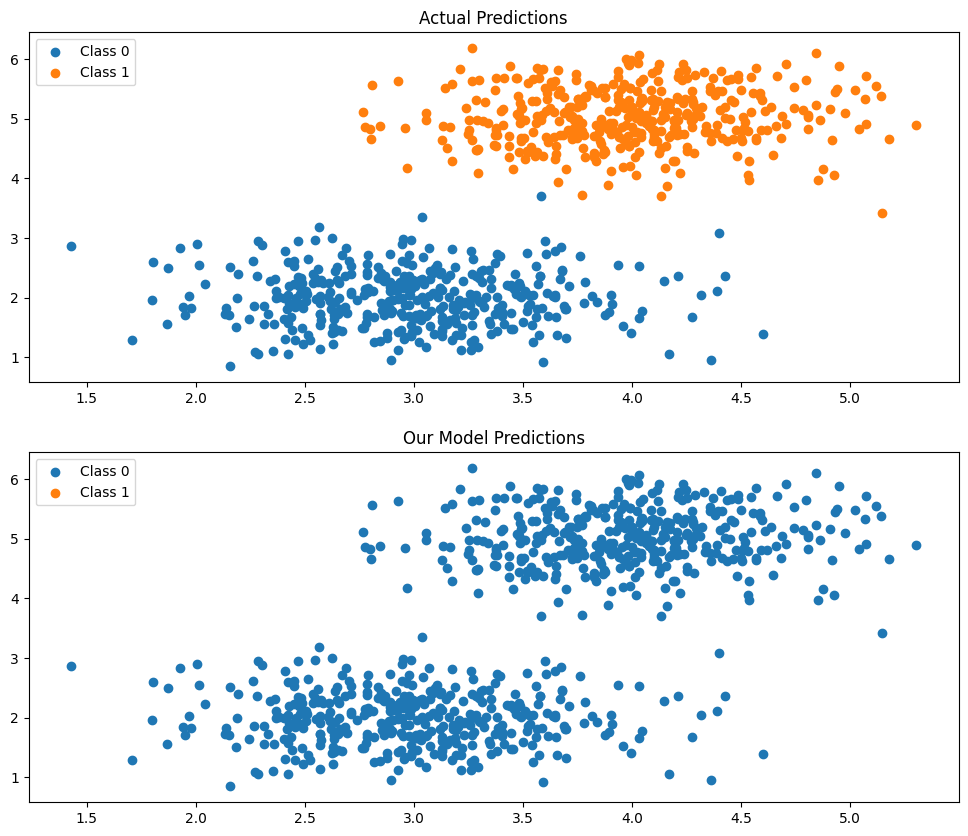

In [ ]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Set the model to evaluation mode (disables dropout, batchnorm updates, etc.).
model.eval()
# Get model predictions on the test data.
model_prediction = model(X_test)

# Convert raw logits to binary predictions (0 or 1) based on a threshold of 0.5.
model_prediction = np.where(model_prediction.cpu() > 0.5, 1, 0)
# Reshape the predictions to a 1D array.
model_prediction = model_prediction.reshape(-1)
# Calculate and print the accuracy score on the test data.
print("Accuracy Score on test data ==>> {}%".format(accuracy_score(model_prediction, y_test.cpu()) * 100))

# Move y_test and X_test back to CPU for plotting.
y_test = y_test.cpu()
X_test = X_test.cpu()

# Create a figure with two subplots for visualization.
fig, ax = plt.subplots(2, 1, figsize=(12, 10))
# Reshape y_test to a 1D array for indexing.
y_test = y_test.view(-1)

# Plot True Predictions (Actual Data)
# Scatter plot for Class 0 (actual labels).
ax[0].scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], label='Class 0', cmap=cm.coolwarm)
# Scatter plot for Class 1 (actual labels).
ax[0].scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], label='Class 1', cmap=cm.coolwarm)
ax[0].set_title('Actual Predictions')
ax[0].legend()

# Plot Model's Predictions
# Scatter plot for Class 0 (model's predictions).
ax[1].scatter(X_test[model_prediction==0, 0], X_test[model_prediction==0, 1], label='Class 0', cmap=cm.coolwarm)
# Scatter plot for Class 1 (model's predictions).
ax[1].scatter(X_test[model_prediction==1, 0], X_test[model_prediction==1, 1], label='Class 1', cmap=cm.coolwarm)
ax[1].set_title('Our Model Predictions')
ax[1].legend()

## Exercise 1: Linear Regression with Gaussian Noise

This exercise follows the specific requirements to generate noisy data, visualize the training process, and test the model on a specific range.

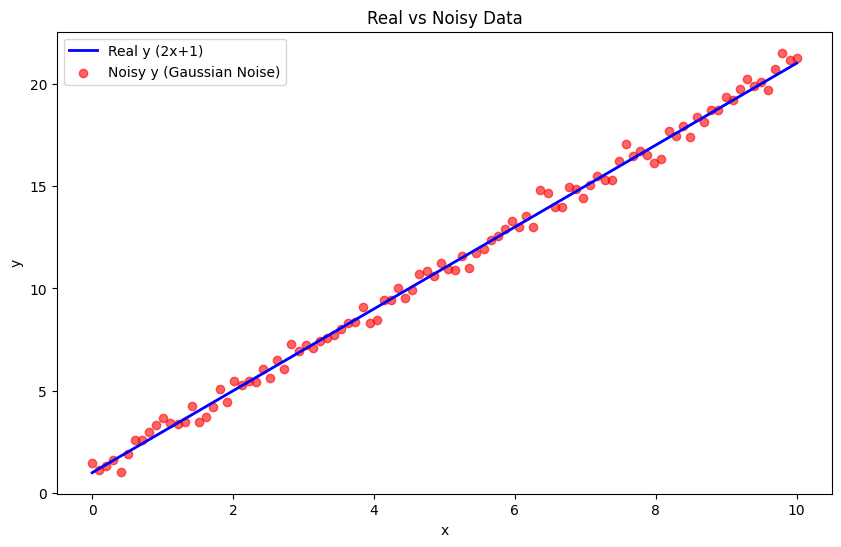

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Generate base data
x_values = torch.linspace(0, 10, 100).reshape(-1, 1)
y_values = 2 * x_values + 1

# Generate y-values with Gaussian Noise
y_values_noise = y_values + 0.4 * torch.randn(x_values.size())

# Plot the real y_values and the noisy y_values_noise
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, label='Real y (2x+1)', color='blue', linewidth=2)
plt.scatter(x_values, y_values_noise, label='Noisy y (Gaussian Noise)', color='red', alpha=0.6)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Real vs Noisy Data')
plt.legend()
plt.show()

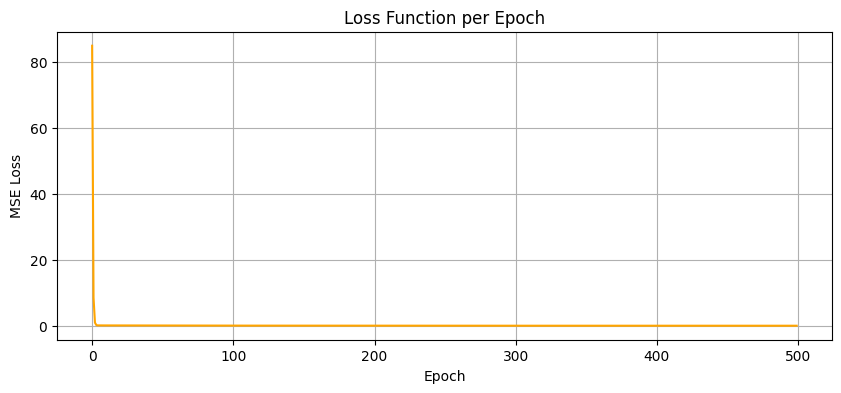

In [2]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

model = LinearRegressionModel()
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Training loop to minimize distance between y_values_noise and y_predicted
epochs = 500
losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    y_predicted = model(x_values)
    loss = criterion(y_predicted, y_values_noise)

    loss.backward()
    optimizer.step()

    losses.append(loss.item())

# Plot your loss function for each epoch
plt.figure(figsize=(10, 4))
plt.plot(losses, color='orange')
plt.title('Loss Function per Epoch')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()

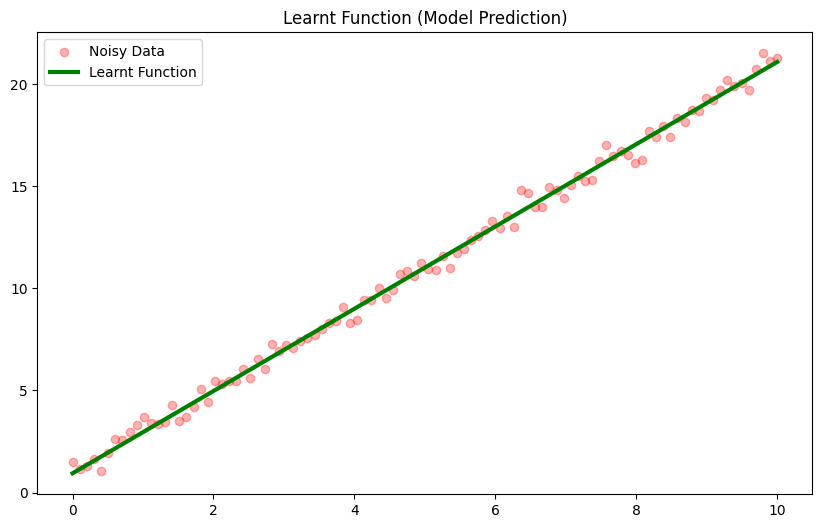

Model State Dictionary (Weights and Bias):
OrderedDict({'linear.weight': tensor([[2.0139]]), 'linear.bias': tensor([0.9444])})


In [3]:
# Plot the learnt function (y_predicted)
model.eval()
with torch.no_grad():
    final_predictions = model(x_values)

plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values_noise, label='Noisy Data', color='red', alpha=0.3)
plt.plot(x_values, final_predictions, label='Learnt Function', color='green', linewidth=3)
plt.title('Learnt Function (Model Prediction)')
plt.legend()
plt.show()

# Print the weights of your model
print("Model State Dictionary (Weights and Bias):")
print(model.state_dict())

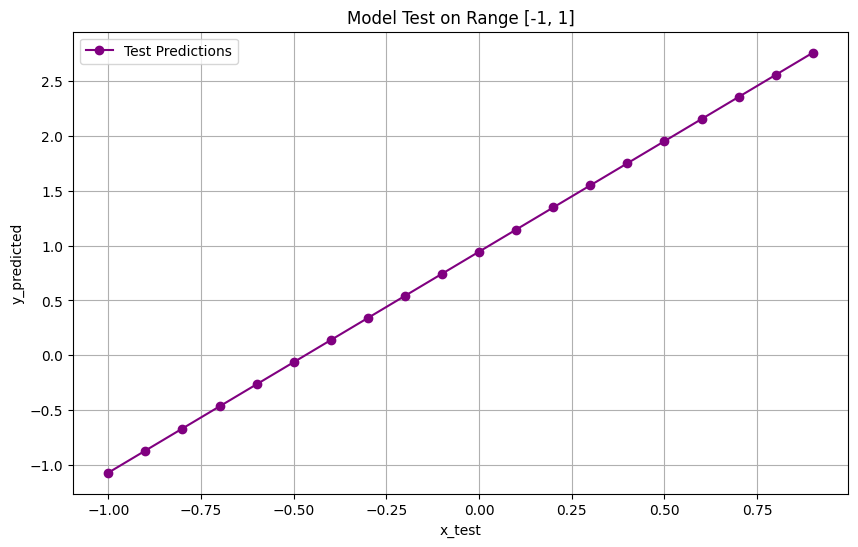

Test Results (x -> y_pred):
-1.0 -> -1.0695
-0.9 -> -0.8682
-0.8 -> -0.6668
-0.7 -> -0.4654
-0.6 -> -0.2640
-0.5 -> -0.0626
-0.4 -> 0.1388
-0.3 -> 0.3402
-0.2 -> 0.5416
-0.1 -> 0.7430
-0.0 -> 0.9444
0.1 -> 1.1458
0.2 -> 1.3472
0.3 -> 1.5485
0.4 -> 1.7499
0.5 -> 1.9513
0.6 -> 2.1527
0.7 -> 2.3541
0.8 -> 2.5555
0.9 -> 2.7569


In [4]:
# Generate x_test-values: torch.arange(-1,1,0.1) and the correspondent y-values
x_test = torch.arange(-1, 1, 0.1).reshape(-1, 1)

# Test your model on the test data
model.eval()
with torch.no_grad():
    y_test_pred = model(x_test)

# Plot test results
plt.figure(figsize=(10, 6))
plt.plot(x_test, y_test_pred, 'o-', label='Test Predictions', color='purple')
plt.title('Model Test on Range [-1, 1]')
plt.xlabel('x_test')
plt.ylabel('y_predicted')
plt.grid(True)
plt.legend()
plt.show()

print("Test Results (x -> y_pred):")
for xt, yt in zip(x_test, y_test_pred):
    print(f"{xt.item():.1f} -> {yt.item():.4f}")

## Exercise 2: Understanding BCE Loss
In this exercise, we compare two different sets of predictions against the same labels to see how the Binary Cross Entropy loss evaluates model performance.

In [5]:
import torch
import torch.nn as nn

# 1. Generate the input arrays (4 x 1)
# Pred1: Generally closer to the actual labels after sigmoid
# Pred2: Generally further or more 'unsure'
Pred1 = torch.tensor([[2.0], [-2.0], [1.5], [-1.0]])
Pred2 = torch.tensor([[-0.5], [0.5], [-1.0], [1.0]])
y = torch.tensor([[1.0], [0.0], [1.0], [0.0]])

# 2. Apply the Sigmoid Function to obtain probabilities
sigmoid = nn.Sigmoid()
prob1 = sigmoid(Pred1)
prob2 = sigmoid(Pred2)

print("Probabilities for Pred1:\n", prob1)
print("Probabilities for Pred2:\n", prob2)

# 3. Calculate Loss Function L(prob, y)
criterion = nn.BCELoss()

loss1 = criterion(prob1, y)
loss2 = criterion(prob2, y)

print(f"\nBCE Loss for Pred1: {loss1.item():.4f}")
print(f"BCE Loss for Pred2: {loss2.item():.4f}")

# 4. Compare results and evaluate
if loss1 < loss2:
    print("\nEvaluation: Pred1 is better because it has a lower BCE loss.")
else:
    print("\nEvaluation: Pred2 is better because it has a lower BCE loss.")

Probabilities for Pred1:
 tensor([[0.8808],
        [0.1192],
        [0.8176],
        [0.2689]])
Probabilities for Pred2:
 tensor([[0.3775],
        [0.6225],
        [0.2689],
        [0.7311]])

BCE Loss for Pred1: 0.1921
BCE Loss for Pred2: 1.1437

Evaluation: Pred1 is better because it has a lower BCE loss.


## Exercise 3: Logistic Regression Evaluation and Decision Boundary
This exercise evaluates the parameters and decision making of the previously trained Logistic Regression model.

Learned Weights (w): [1.8472117 1.0513296]
Learned Bias (b): 0.13727053999900818


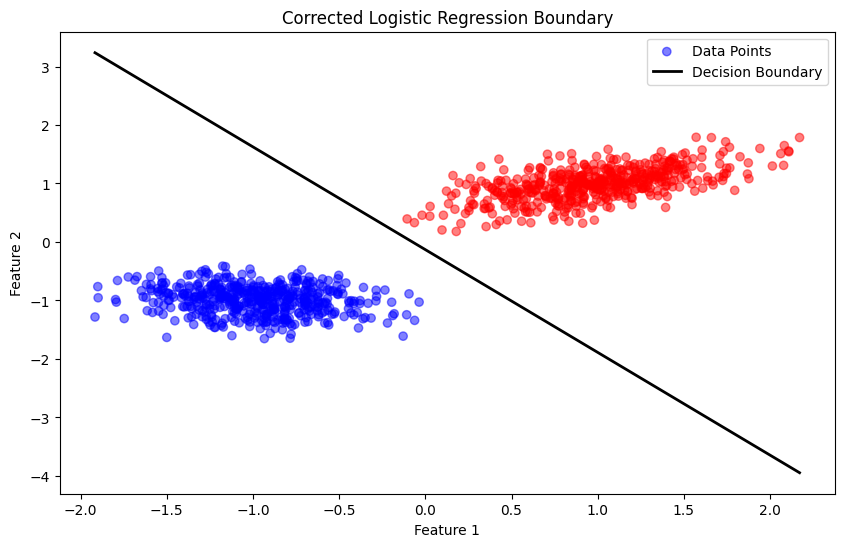

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Use model_logistic and inputs_lr
params = list(model_logistic.parameters())
w = params[0].detach().numpy()[0]
b = params[1].detach().numpy()[0]

print(f"Learned Weights (w): {w}")
print(f"Learned Bias (b): {b}")

plt.figure(figsize=(10, 6))
plt.scatter(inputs_lr[:, 0], inputs_lr[:, 1], c=labels_lr, cmap='bwr', alpha=0.5, label='Data Points')

x1_range = np.linspace(inputs_lr[:, 0].min(), inputs_lr[:, 0].max(), 100)
x2_boundary = -(w[0] * x1_range + b) / w[1]

plt.plot(x1_range, x2_boundary, color='black', linewidth=2, label='Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Corrected Logistic Regression Boundary')
plt.legend()
plt.show()

In [13]:
from sklearn.datasets import make_classification
import torch

# Test dataset with 2 features for the 2D model
X_test_new, y_test_new = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                             n_informative=2, n_clusters_per_class=1, random_state=10)
X_test_tensor = torch.from_numpy(X_test_new).float()

model_logistic.eval()
with torch.no_grad():
    test_outputs = model_logistic(X_test_tensor)
    test_preds = (test_outputs >= 0.5).float().squeeze()

# Fix: Convert boolean tensor to float before taking the mean
accuracy = (test_preds == torch.from_numpy(y_test_new).float()).float().mean()
print(f"Accuracy on new test data: {accuracy.item() * 100:.2f}%")

Accuracy on new test data: 36.50%


### What happens if data is not linearly separable?
If the data is not linearly separable (meaning a straight line cannot divide the classes), a simple Logistic Regression model will:
1. **Fail to reach zero loss**: The BCE loss will plateau at a higher value.
2. **Misclassify points**: There will be points from both classes on the 'wrong' side of the boundary line.
3. **Underfit**: The model is limited by its linear nature. To solve this, you would need to add non-linear features or use a deeper Neural Network (like the Shallow Neural Network shown earlier in the notebook).

## Exercise 4: Experimenting with Shallow Neural Networks
In this exercise, we use a non-linearly separable dataset (`make_moons`) and experiment with the network architecture and hyperparameters.

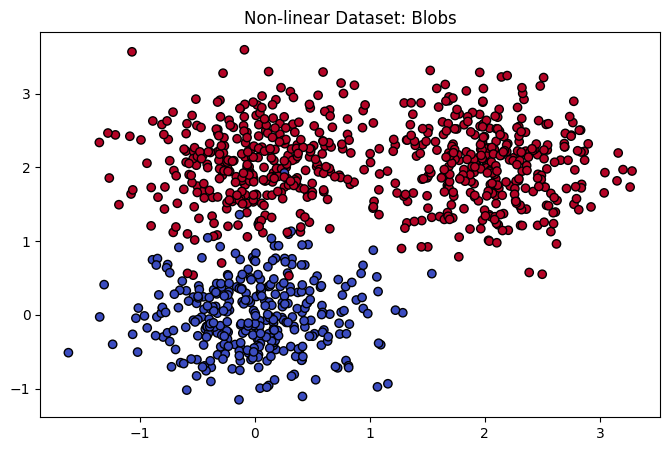

In [20]:
from sklearn.datasets import make_blobs

# 1. Generate a blobs dataset with 3 centers but only 2 classes (making it non-linear)
X_blobs, y_blobs = make_blobs(n_samples=1000, centers=[[0,0], [2,2], [0,2]], cluster_std=0.5, random_state=42)
# Map 3 clusters to 2 classes to ensure non-linearity
y_blobs = (y_blobs > 0).astype(float)

# Split and convert to tensors
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_blobs, y_blobs, test_size=0.2, random_state=42)

X_train_b = torch.FloatTensor(X_train_b)
X_test_b = torch.FloatTensor(X_test_b)
y_train_b = torch.FloatTensor(y_train_b).view(-1, 1)
y_test_b = torch.FloatTensor(y_test_b).view(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap='coolwarm', edgecolors='k')
plt.title("Non-linear Dataset: Blobs")
plt.show()

Final Blobs Accuracy: 97.00%


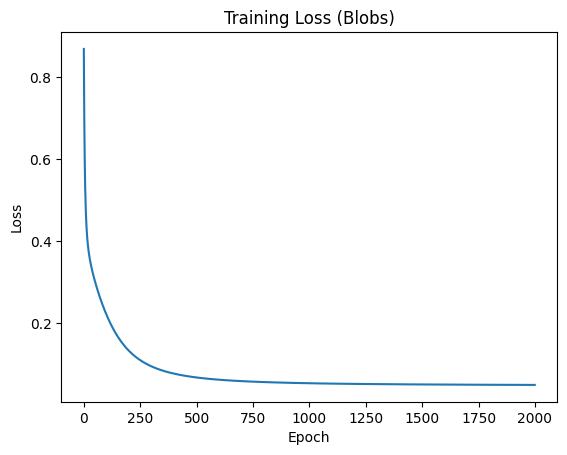

In [21]:
# 2. Configuration for Blobs
HIDDEN_UNITS_B = 16
LEARNING_RATE_B = 0.05
EPOCHS_B = 2000

model_blobs = ShallowNet(2, HIDDEN_UNITS_B)
criterion_b = nn.BCELoss()
optimizer_b = torch.optim.SGD(model_blobs.parameters(), lr=LEARNING_RATE_B)

# 3. Training Loop
losses_b = []
for epoch in range(EPOCHS_B):
    model_blobs.train()
    optimizer_b.zero_grad()
    y_pred = model_blobs(X_train_b)
    loss = criterion_b(y_pred, y_train_b)
    loss.backward()
    optimizer_b.step()
    losses_b.append(loss.item())

# 4. Evaluation
model_blobs.eval()
with torch.no_grad():
    test_preds = (model_blobs(X_test_b) > 0.5).float()
    accuracy = (test_preds == y_test_b).float().mean()

print(f"Final Blobs Accuracy: {accuracy.item()*100:.2f}%")

plt.plot(losses_b)
plt.title("Training Loss (Blobs)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

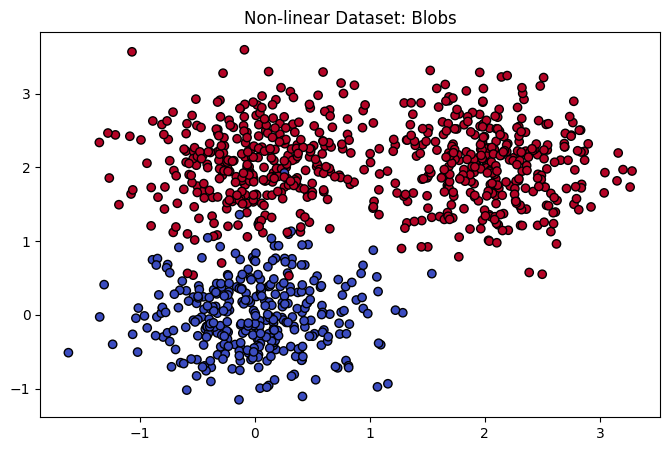

In [22]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. Generate a blobs dataset with 3 centers but only 2 classes (making it non-linear)
X_blobs, y_blobs = make_blobs(n_samples=1000, centers=[[0,0], [2,2], [0,2]], cluster_std=0.5, random_state=42)
# Map 3 clusters to 2 classes to ensure non-linearity
y_blobs = (y_blobs > 0).astype(float)

# Split and convert to tensors
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_blobs, y_blobs, test_size=0.2, random_state=42)

X_train_b = torch.FloatTensor(X_train_b)
X_test_b = torch.FloatTensor(X_test_b)
y_train_b = torch.FloatTensor(y_train_b).view(-1, 1)
y_test_b = torch.FloatTensor(y_test_b).view(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap='coolwarm', edgecolors='k')
plt.title("Non-linear Dataset: Blobs")
plt.show()

Final Blobs Accuracy: 98.00%


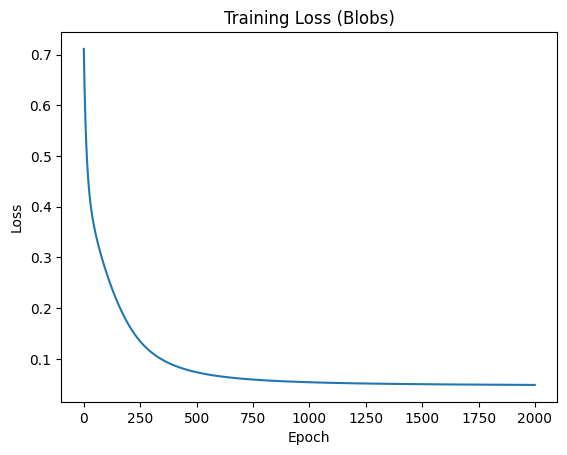

In [23]:
# 2. Configuration for Blobs (Experiment with these!)
HIDDEN_UNITS_B = 16
LEARNING_RATE_B = 0.05
EPOCHS_B = 2000

# Using the ShallowNet class defined previously
model_blobs = ShallowNet(2, HIDDEN_UNITS_B)
criterion_b = nn.BCELoss()
optimizer_b = torch.optim.SGD(model_blobs.parameters(), lr=LEARNING_RATE_B)

# 3. Training Loop
losses_b = []
for epoch in range(EPOCHS_B):
    model_blobs.train()
    optimizer_b.zero_grad()
    y_pred = model_blobs(X_train_b)
    loss = criterion_b(y_pred, y_train_b)
    loss.backward()
    optimizer_b.step()
    losses_b.append(loss.item())

# 4. Evaluation
model_blobs.eval()
with torch.no_grad():
    test_preds = (model_blobs(X_test_b) > 0.5).float()
    accuracy = (test_preds == y_test_b).float().mean()

print(f"Final Blobs Accuracy: {accuracy.item()*100:.2f}%")

plt.plot(losses_b)
plt.title("Training Loss (Blobs)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

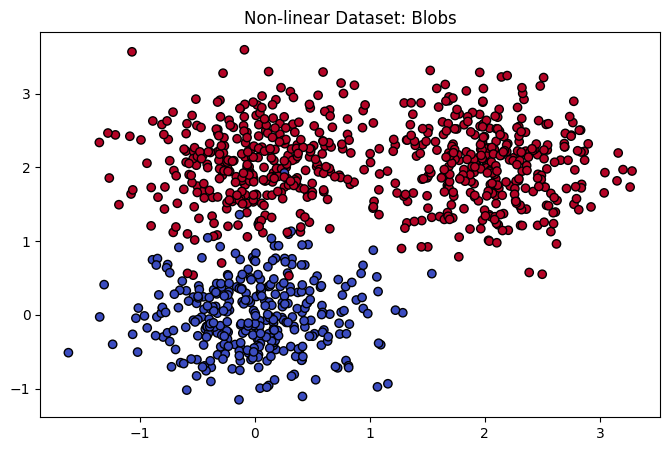

In [24]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. Generate a blobs dataset with 3 centers but only 2 classes (making it non-linear)
X_blobs, y_blobs = make_blobs(n_samples=1000, centers=[[0,0], [2,2], [0,2]], cluster_std=0.5, random_state=42)
# Map 3 clusters to 2 classes to ensure non-linearity
y_blobs = (y_blobs > 0).astype(float)

# Split and convert to tensors
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_blobs, y_blobs, test_size=0.2, random_state=42)

X_train_b = torch.FloatTensor(X_train_b)
X_test_b = torch.FloatTensor(X_test_b)
y_train_b = torch.FloatTensor(y_train_b).view(-1, 1)
y_test_b = torch.FloatTensor(y_test_b).view(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap='coolwarm', edgecolors='k')
plt.title("Non-linear Dataset: Blobs")
plt.show()

Final Blobs Accuracy: 98.00%


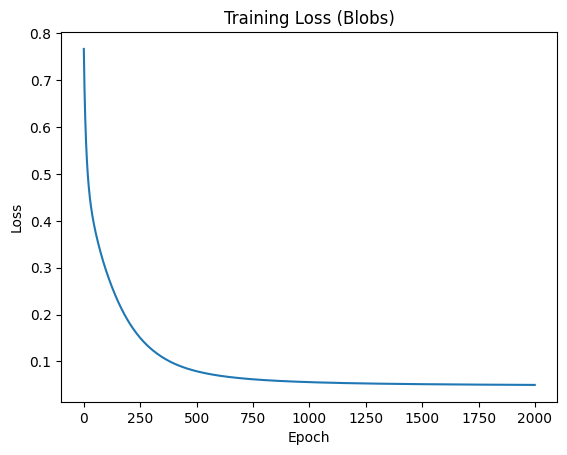

In [25]:
# 2. Configuration for Blobs (Experiment with these!)
HIDDEN_UNITS_B = 16
LEARNING_RATE_B = 0.05
EPOCHS_B = 2000

# Using the ShallowNet class defined previously
model_blobs = ShallowNet(2, HIDDEN_UNITS_B)
criterion_b = nn.BCELoss()
optimizer_b = torch.optim.SGD(model_blobs.parameters(), lr=LEARNING_RATE_B)

# 3. Training Loop
losses_b = []
for epoch in range(EPOCHS_B):
    model_blobs.train()
    optimizer_b.zero_grad()
    y_pred = model_blobs(X_train_b)
    loss = criterion_b(y_pred, y_train_b)
    loss.backward()
    optimizer_b.step()
    losses_b.append(loss.item())

# 4. Evaluation
model_blobs.eval()
with torch.no_grad():
    test_preds = (model_blobs(X_test_b) > 0.5).float()
    accuracy = (test_preds == y_test_b).float().mean()

print(f"Final Blobs Accuracy: {accuracy.item()*100:.2f}%")

plt.plot(losses_b)
plt.title("Training Loss (Blobs)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

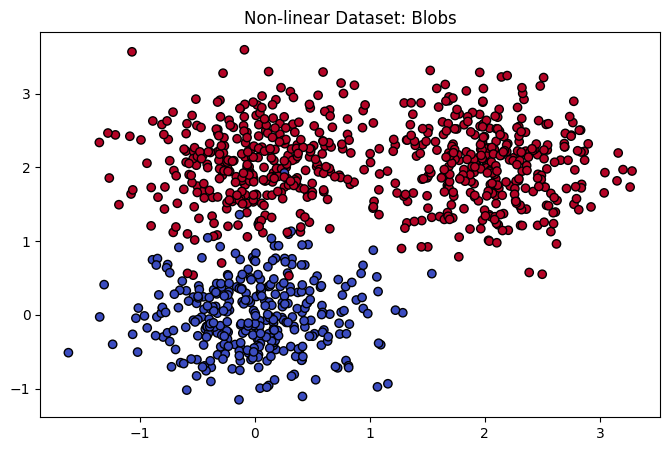

In [26]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. Generate a blobs dataset with 3 centers but only 2 classes (making it non-linear)
X_blobs, y_blobs = make_blobs(n_samples=1000, centers=[[0,0], [2,2], [0,2]], cluster_std=0.5, random_state=42)
# Map 3 clusters to 2 classes to ensure non-linearity
y_blobs = (y_blobs > 0).astype(float)

# Split and convert to tensors
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_blobs, y_blobs, test_size=0.2, random_state=42)

X_train_b = torch.FloatTensor(X_train_b)
X_test_b = torch.FloatTensor(X_test_b)
y_train_b = torch.FloatTensor(y_train_b).view(-1, 1)
y_test_b = torch.FloatTensor(y_test_b).view(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap='coolwarm', edgecolors='k')
plt.title("Non-linear Dataset: Blobs")
plt.show()

Final Blobs Accuracy: 97.50%


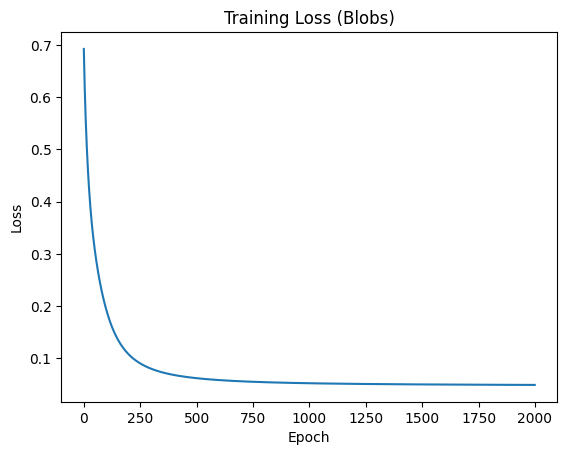

In [27]:
# 2. Configuration for Blobs (Experiment with these!)
HIDDEN_UNITS_B = 16
LEARNING_RATE_B = 0.05
EPOCHS_B = 2000

# Using the ShallowNet class defined previously
model_blobs = ShallowNet(2, HIDDEN_UNITS_B)
criterion_b = nn.BCELoss()
optimizer_b = torch.optim.SGD(model_blobs.parameters(), lr=LEARNING_RATE_B)

# 3. Training Loop
losses_b = []
for epoch in range(EPOCHS_B):
    model_blobs.train()
    optimizer_b.zero_grad()
    y_pred = model_blobs(X_train_b)
    loss = criterion_b(y_pred, y_train_b)
    loss.backward()
    optimizer_b.step()
    losses_b.append(loss.item())

# 4. Evaluation
model_blobs.eval()
with torch.no_grad():
    test_preds = (model_blobs(X_test_b) > 0.5).float()
    accuracy = (test_preds == y_test_b).float().mean()

print(f"Final Blobs Accuracy: {accuracy.item()*100:.2f}%")

plt.plot(losses_b)
plt.title("Training Loss (Blobs)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

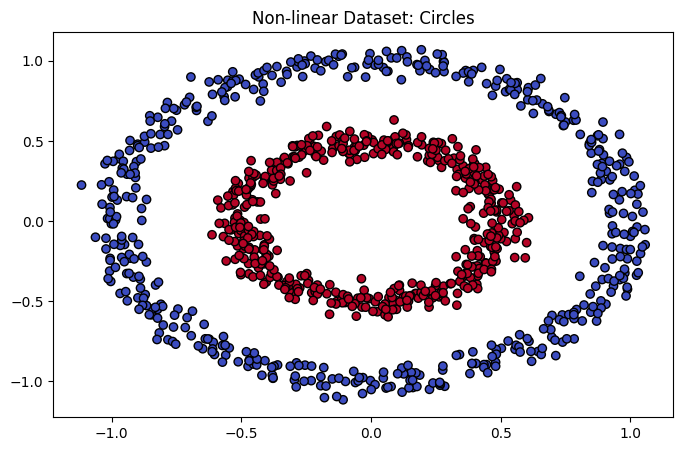

In [16]:
from sklearn.datasets import make_circles

# 1. Generate a concentric circles dataset
X_circles, y_circles = make_circles(n_samples=1000, noise=0.05, factor=0.5, random_state=42)

# Split and convert to tensors
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_circles, y_circles, test_size=0.2, random_state=42)

X_train_c = torch.FloatTensor(X_train_c)
X_test_c = torch.FloatTensor(X_test_c)
y_train_c = torch.FloatTensor(y_train_c).view(-1, 1)
y_test_c = torch.FloatTensor(y_test_c).view(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='coolwarm', edgecolors='k')
plt.title("Non-linear Dataset: Circles")
plt.show()

Final Circles Accuracy: 99.50%


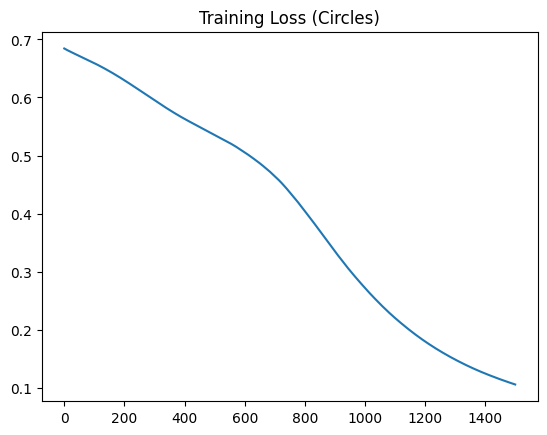

In [17]:
# 2. Configuration for Circles
HIDDEN_UNITS_C = 12
LEARNING_RATE_C = 0.1
EPOCHS_C = 1500

model_circles = ShallowNet(2, HIDDEN_UNITS_C)
criterion_c = nn.BCELoss()
optimizer_c = torch.optim.SGD(model_circles.parameters(), lr=LEARNING_RATE_C)

# 3. Training Loop
losses_c = []
for epoch in range(EPOCHS_C):
    model_circles.train()
    optimizer_c.zero_grad()
    y_pred = model_circles(X_train_c)
    loss = criterion_c(y_pred, y_train_c)
    loss.backward()
    optimizer_c.step()
    losses_c.append(loss.item())

# 4. Evaluation
model_circles.eval()
with torch.no_grad():
    test_preds = (model_circles(X_test_c) > 0.5).float()
    accuracy = (test_preds == y_test_c).float().mean()

print(f"Final Circles Accuracy: {accuracy.item()*100:.2f}%")

plt.plot(losses_c)
plt.title("Training Loss (Circles)")
plt.show()

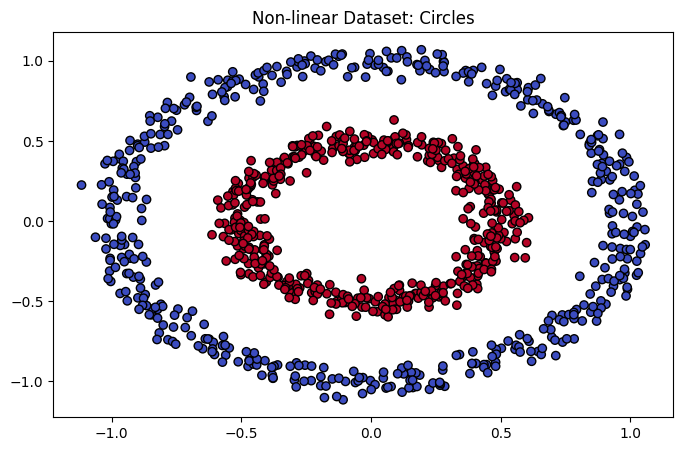

In [18]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. Generate a concentric circles dataset
X_circles, y_circles = make_circles(n_samples=1000, noise=0.05, factor=0.5, random_state=42)

# Split and convert to tensors
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_circles, y_circles, test_size=0.2, random_state=42)

X_train_c = torch.FloatTensor(X_train_c)
X_test_c = torch.FloatTensor(X_test_c)
y_train_c = torch.FloatTensor(y_train_c).view(-1, 1)
y_test_c = torch.FloatTensor(y_test_c).view(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='coolwarm', edgecolors='k')
plt.title("Non-linear Dataset: Circles")
plt.show()

Final Circles Accuracy: 100.00%


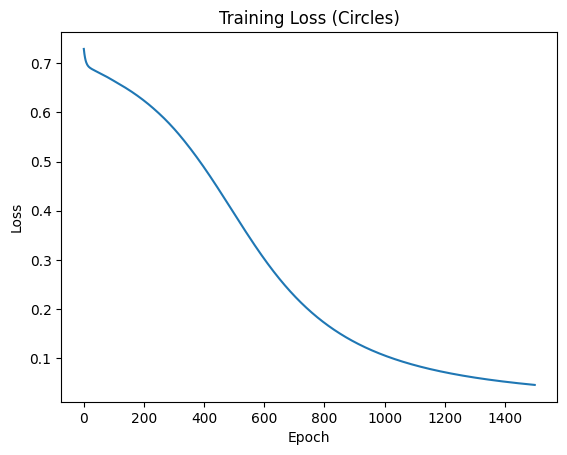

In [19]:
# 2. Configuration for Circles (Experiment with these!)
HIDDEN_UNITS_C = 12
LEARNING_RATE_C = 0.1
EPOCHS_C = 1500

# Using the ShallowNet class defined in the previous cell
model_circles = ShallowNet(2, HIDDEN_UNITS_C)
criterion_c = nn.BCELoss()
optimizer_c = torch.optim.SGD(model_circles.parameters(), lr=LEARNING_RATE_C)

# 3. Training Loop
losses_c = []
for epoch in range(EPOCHS_C):
    model_circles.train()
    optimizer_c.zero_grad()
    y_pred = model_circles(X_train_c)
    loss = criterion_c(y_pred, y_train_c)
    loss.backward()
    optimizer_c.step()
    losses_c.append(loss.item())

# 4. Evaluation
model_circles.eval()
with torch.no_grad():
    test_preds = (model_circles(X_test_c) > 0.5).float()
    accuracy = (test_preds == y_test_c).float().mean()

print(f"Final Circles Accuracy: {accuracy.item()*100:.2f}%")

plt.plot(losses_c)
plt.title("Training Loss (Circles)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

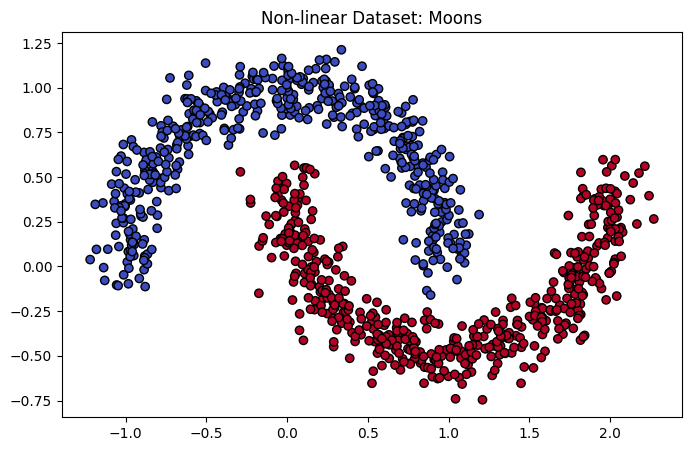

In [14]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# 1. Generate a non-linear dataset (Moons)
X_moons, y_moons = make_moons(n_samples=1000, noise=0.1, random_state=42)

# Split and convert to tensors
X_train, X_test, y_train, y_test = train_test_split(X_moons, y_moons, test_size=0.2, random_state=42)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train).view(-1, 1)
y_test = torch.FloatTensor(y_test).view(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm', edgecolors='k')
plt.title("Non-linear Dataset: Moons")
plt.show()

Final Accuracy: 92.50%


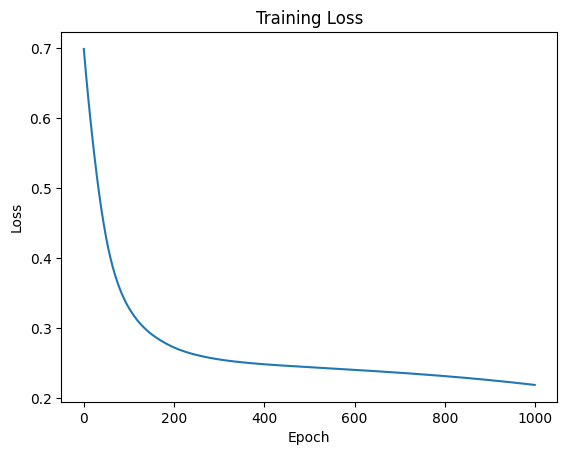

In [15]:
# 2. Configuration (Experiment with these values!)
HIDDEN_UNITS = 10
LEARNING_RATE = 0.1
EPOCHS = 1000

class ShallowNet(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.sigmoid(self.layer2(x))
        return x

model_ex4 = ShallowNet(2, HIDDEN_UNITS)
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model_ex4.parameters(), lr=LEARNING_RATE)

# 3. Training Loop
losses = []
for epoch in range(EPOCHS):
    model_ex4.train()
    optimizer.zero_grad()
    y_pred = model_ex4(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

# 4. Evaluation
model_ex4.eval()
with torch.no_grad():
    test_preds = (model_ex4(X_test) > 0.5).float()
    accuracy = (test_preds == y_test).float().mean()

print(f"Final Accuracy: {accuracy.item()*100:.2f}%")

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()